In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Настройки для красивых графиков
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore')

In [10]:
import os
file_path = "data/raw/game_offers.csv"
# Проверяем наличие файла
if not os.path.exists(file_path):
    print(f" Файл не найден: {file_path}")
    print(f" Jupyter работает в: {os.getcwd()}")
else:
    print(f" Файл найден. Загружаю данные...")
    
    # Загрузка
    df = pd.read_csv(file_path)
    
    # Обработка типов
    df['dt'] = pd.to_datetime(df['dt'])
    df['purchase_value'] = pd.to_numeric(df['purchase_value'], errors='coerce')
    df.dropna(subset=['dt', 'client_id'], inplace=True)
    
    # Вывод результата
    print(f" Загружено строк: {len(df)}")
    print(f" Уникальных игроков: {df['client_id'].nunique()}")
    print(f" Период: {df['dt'].min().date()} — {df['dt'].max().date()}")
    df.info()
   

 Файл найден. Загружаю данные...
 Загружено строк: 100
 Уникальных игроков: 98
 Период: 2025-04-01 — 2025-04-29
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   dt              100 non-null    datetime64[ns]
 1   client_id       100 non-null    int64         
 2   event_type      100 non-null    object        
 3   offer_type      100 non-null    object        
 4   level           100 non-null    int64         
 5   purchase_value  6 non-null      float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 4.8+ KB


In [14]:
# Добавляем колонку с датой (без времени)
df['date'] = df['dt'].dt.date

# Группируем: один игрок + один день = одна строка
daily_funnel = df.groupby(['client_id', 'date']).agg(
    views=('event_type', lambda x: (x == 'offer_view').sum()),
    clicks=('event_type', lambda x: (x == 'offer_click').sum()),
    purchases=('event_type', lambda x: (x == 'purchase').sum()),
    amount=('purchase_value', 'sum'),
    level_max=('level', 'max'),
    offer_type=('offer_type', 'first')  # Сохраняем стиль игры
).reset_index()

#  Переименовываем client_id → user_id (как в ТЗ)
daily_funnel.rename(columns={'client_id': 'user_id'}, inplace=True)

print(" Воронка по дням построена.")
print(f" Строк в агрегированной таблице: {len(daily_funnel)}")
print(f" Уникальных игроков: {daily_funnel['user_id'].nunique()}")
print(f" Дней в данных: {daily_funnel['date'].nunique()}")
daily_funnel.head(10)

 Воронка по дням построена.
 Строк в агрегированной таблице: 100
 Уникальных игроков: 98
 Дней в данных: 29


,user_id,date,views,clicks,purchases,amount,level_max,offer_type
0,3002,2025-04-08,1,0,0,0.0,38,Rogue
1,3009,2025-04-08,0,0,0,0.0,19,Healer
2,3016,2025-04-18,1,0,0,0.0,9,Warrior
3,3025,2025-04-07,0,1,0,0.0,40,Rogue
4,3026,2025-04-20,1,0,0,0.0,16,Rogue
5,3031,2025-04-19,1,0,0,0.0,26,Healer
6,3064,2025-04-07,0,1,0,0.0,45,Healer
7,3101,2025-04-28,0,0,0,0.0,41,Mage
8,3110,2025-04-13,0,1,0,0.0,5,Healer
9,3146,2025-04-27,1,0,0,0.0,30,Rogue


In [17]:
# Считаем метрики для каждого игрока за весь период
user_metrics = df.groupby('client_id').agg(
    total_views=('event_type', lambda x: (x == 'offer_view').sum()),
    total_purchases=('event_type', lambda x: (x == 'purchase').sum()),
    total_amount=('purchase_value', 'sum'),
    offer_type=('offer_type', 'first')
).reset_index()

# CR_purchase = покупки / показы (только если были показы)
user_metrics['user_cr'] = np.where(
    user_metrics['total_views'] > 0,
    user_metrics['total_purchases'] / user_metrics['total_views'],
    np.nan
)

# D7 Retention: вернулся ли игрок ровно на 7-й день после первого появления
# 1. Находим дату первого появления каждого игрока
first_day = df.groupby('client_id')['dt'].min().reset_index()
first_day.rename(columns={'dt': 'first_dt'}, inplace=True)

# 2. Вычисляем дату 7-го дня
first_day['day7'] = first_day['first_dt'] + pd.Timedelta(days=7)

# 3. Проверяем, есть ли активность в этот день
df_with_day7 = df.merge(first_day[['client_id', 'day7']], on='client_id', how='left')
df_with_day7['is_day7'] = df_with_day7['dt'].dt.normalize() == df_with_day7['day7'].dt.normalize()
d7_users = df_with_day7[df_with_day7['is_day7']]['client_id'].unique()

# 4. Помечаем игроков, вернувшихся на 7-й день
user_metrics['d7_retained'] = user_metrics['client_id'].isin(d7_users).astype(int)

# ARPPU считаем только для тех, кто покупал
purchasers = user_metrics[user_metrics['total_purchases'] > 0].copy()
purchasers['user_arppu'] = purchasers['total_amount'] / purchasers['total_purchases']

print(" Метрики рассчитаны.")
print(f" Игроков с показами: {user_metrics['total_views'].sum()}")
print(f" Покупателей: {len(purchasers)}")
print(f" Вернулись на 7-й день: {user_metrics['d7_retained'].sum()}")
print(f"\n Средние значения:")
print(f"   CR_purchase: {user_metrics['user_cr'].mean():.4f}")
print(f"   ARPPU: {purchasers['user_arppu'].mean():.2f}")
print(f"   D7_retention: {user_metrics['d7_retained'].mean():.4f}")
# Смотрим примеры
user_metrics[['client_id', 'total_views', 'total_purchases', 'total_amount', 'user_cr', 'd7_retained']].head(10)

 Метрики рассчитаны.
 Игроков с показами: 38
 Покупателей: 6
 Вернулись на 7-й день: 0

 Средние значения:
   CR_purchase: 0.0526
   ARPPU: 62.67
   D7_retention: 0.0000


,client_id,total_views,total_purchases,total_amount,user_cr,d7_retained
0,3002,1,0,0.0,0.0,0
1,3009,0,0,0.0,NaN,0
2,3016,1,0,0.0,0.0,0
3,3025,0,0,0.0,NaN,0
4,3026,1,0,0.0,0.0,0
5,3031,1,0,0.0,0.0,0
6,3064,0,0,0.0,NaN,0
7,3101,0,0,0.0,NaN,0
8,3110,0,0,0.0,NaN,0
9,3146,1,0,0.0,0.0,0


In [18]:
# Функция для расчёта дисперсии отношения (Delta-метод из ТЗ)
def var_ratio(x, y):
    """Расчёт дисперсии для метрик типа 'отношение двух величин'"""
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    var_x = np.var(x, ddof=1)  # ddof=1 → несмещённая оценка
    var_y = np.var(y, ddof=1)
    cov_xy = np.cov(x, y, ddof=1)[0][1]  # ковариация
    result = (var_x / mean_y**2 + 
              var_y * mean_x**2 / mean_y**4 - 
              2 * mean_x * cov_xy / mean_y**3)
    return result

#  CR_purchase: считаем на тех, у кого были показы
user_cr_data = user_metrics.dropna(subset=['user_cr'])
x_cr = user_cr_data['total_purchases'].values
y_cr = user_cr_data['total_views'].values

cr_mean = np.mean(x_cr) / np.mean(y_cr)
cr_var = var_ratio(x_cr, y_cr)
cr_std = np.sqrt(cr_var)

#  ARPPU: только среди покупателей
arppu_mean = purchasers['total_amount'].sum() / purchasers['total_purchases'].sum()
arppu_std = purchasers['user_arppu'].std()
arppu_var = purchasers['user_arppu'].var()

#  D7 Retention: бинарная метрика (0 или 1)
d7_mean = user_metrics['d7_retained'].mean()
d7_var = d7_mean * (1 - d7_mean)  # формула для дисперсии бинарной величины
d7_std = np.sqrt(d7_var)

#  Выводим результаты в удобном формате
print(" СТАТИСТИКИ ПО МЕТРИКАМ (user-level):")
print("="*50)
print(f"\n CR_purchase:")
print(f"   Среднее: {cr_mean:.4f} ({cr_mean*100:.2f}%)")
print(f"   Дисперсия: {cr_var:.6f}")
print(f"   Std (σ): {cr_std:.4f}")

print(f"\n ARPPU:")
print(f"   Среднее: {arppu_mean:.2f}")
print(f"   Дисперсия: {arppu_var:.2f}")
print(f"   Std (σ): {arppu_std:.2f}")

print(f"\n D7 Retention:")
print(f"   Среднее: {d7_mean:.4f} ({d7_mean*100:.2f}%)")
print(f"   Дисперсия: {d7_var:.6f}")
print(f"   Std (σ): {d7_std:.4f}")
print("="*50)

 СТАТИСТИКИ ПО МЕТРИКАМ (user-level):

 CR_purchase:
   Среднее: 0.0526 (5.26%)
   Дисперсия: 0.051209
   Std (σ): 0.2263

 ARPPU:
   Среднее: 62.67
   Дисперсия: 1353.87
   Std (σ): 36.79

 D7 Retention:
   Среднее: 0.0000 (0.00%)
   Дисперсия: 0.000000
   Std (σ): 0.0000


In [21]:
# Шаг 6: Моделируем A/B-сплит и считаем метрики по группам

#  1. Создаём колонку ab_group
# В реальном проекте она фиксируется при установке игры, здесь моделируем случайно.
if 'ab_group' not in user_metrics.columns:
    np.random.seed(42)  # Фиксируем случайность
    user_metrics['ab_group'] = np.random.choice(
        ['Control', 'Test'], 
        size=len(user_metrics), 
        p=[0.5, 0.5]  # Делим 50/50
    )
    print(" Группа A/B создана (Control/Test).")
else:
    print(" Группа A/B уже есть.")

#  2. Агрегируем суммы по группам
agg_data = user_metrics.groupby('ab_group').agg({
    'client_id': 'count',         # Сколько игроков в группе
    'total_views': 'sum',         # Сумма показов
    'total_purchases': 'sum',     # Сумма покупок
    'total_amount': 'sum',        # Сумма выручки
    'd7_retained': 'sum'          # Сколько вернулось на 7-й день
})

# 3. Считаем количество уникальных покупателей (тех, у кого > 0 покупок)
purchasers_count = user_metrics[user_metrics['total_purchases'] > 0].groupby('ab_group')['client_id'].count()

# 4. Рассчитываем итоговые метрики вручную (чтобы избежать ошибок индексов)
metrics = {}
for g in ['Control', 'Test']:
    if g in agg_data.index:
        u = agg_data.loc[g, 'client_id']
        v = agg_data.loc[g, 'total_views']
        p = agg_data.loc[g, 'total_purchases']
        a = agg_data.loc[g, 'total_amount']
        d = agg_data.loc[g, 'd7_retained']
        np_buy = purchasers_count.get(g, 0)

        metrics[g] = {
            'n_users': u, 
            'views': v, 
            'purchases': p, 
            'amount': a,
            'purchasers': np_buy, 
            'd7': d,
            'CR': p/v if v>0 else 0,          # Конверсия
            'ARPPU': a/np_buy if np_buy>0 else 0, # Выручка на покупателя
            'D7': d/u if u>0 else 0           # Удержание
        }

# 5. Создаём таблицу для сравнения
group_stats = pd.DataFrame(metrics)
group_stats['Delta'] = group_stats['Test'] - group_stats['Control']
group_stats['Lift_%'] = np.where(group_stats['Control'] != 0, 
                                 group_stats['Delta'] / group_stats['Control'] * 100, 0)

print("\n МЕТРИКИ ПО ГРУППАМ:")
print("="*60)
print(group_stats.round(4))
print("="*60)

#  Выводим главные дельты для отчёта
cr_c, cr_t = metrics['Control']['CR'], metrics['Test']['CR']
arppu_c, arppu_t = metrics['Control']['ARPPU'], metrics['Test']['ARPPU']
d7_c, d7_t = metrics['Control']['D7'], metrics['Test']['D7']

print(f"\n CR_purchase: Control={cr_c:.4f}, Test={cr_t:.4f}, Lift={group_stats.loc['CR','Lift_%']:+.2f}%")
print(f" ARPPU: Control={arppu_c:.2f}, Test={arppu_t:.2f}, Lift={group_stats.loc['ARPPU','Lift_%']:+.2f}%")
print(f" D7: Control={d7_c:.4f}, Test={d7_t:.4f}, Lift={group_stats.loc['D7','Lift_%']:+.2f}%")

 Группа A/B уже есть.

 МЕТРИКИ ПО ГРУППАМ:
             Control      Test    Delta   Lift_%
n_users      51.0000   47.0000  -4.0000  -7.8431
views        23.0000   15.0000  -8.0000 -34.7826
purchases     4.0000    2.0000  -2.0000 -50.0000
amount      194.0000  182.0000 -12.0000  -6.1856
purchasers    4.0000    2.0000  -2.0000 -50.0000
d7            0.0000    0.0000   0.0000   0.0000
CR            0.1739    0.1333  -0.0406 -23.3333
ARPPU        48.5000   91.0000  42.5000  87.6289
D7            0.0000    0.0000   0.0000   0.0000

 CR_purchase: Control=0.1739, Test=0.1333, Lift=-23.33%
 ARPPU: Control=48.50, Test=91.00, Lift=+87.63%
 D7: Control=0.0000, Test=0.0000, Lift=+0.00%


In [23]:
# Шаг 7: Проверка статистической значимости (p-value)
print(" ПРОВЕРКА СТАТИСТИЧЕСКОЙ ЗНАЧИМОСТИ")
print("="*50)

# Разделяем данные по группам
ctrl = user_metrics[user_metrics['ab_group'] == 'Control']
test = user_metrics[user_metrics['ab_group'] == 'Test']

#  1. CR_Purchase (Z-тест для пропорций) 
n_ctrl_views = ctrl['total_views'].sum()
x_ctrl_purch = ctrl['total_purchases'].sum()
n_test_views = test['total_views'].sum()
x_test_purch = test['total_purchases'].sum()

p_cr = np.nan
if n_ctrl_views > 0 and n_test_views > 0:
    p1 = x_ctrl_purch / n_ctrl_views
    p2 = x_test_purch / n_test_views
    p_pooled = (x_ctrl_purch + x_test_purch) / (n_ctrl_views + n_test_views)
    se = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_ctrl_views + 1/n_test_views))
    if se > 0:
        z_cr = (p1 - p2) / se
        p_cr = 2 * stats.norm.sf(abs(z_cr))  # sf = survival function

p_cr_str = f"{p_cr:.4f}" if not np.isnan(p_cr) else "Нет данных"
sig_cr = " Значимо" if (not np.isnan(p_cr) and p_cr < 0.05) else " Не значимо"
print(f" CR_purchase: p-value = {p_cr_str} | {sig_cr}")

#  2. D7 Retention (Z-тест для долей) 
n_ctrl = len(ctrl)
x_ctrl_ret = ctrl['d7_retained'].sum()
n_test = len(test)
x_test_ret = test['d7_retained'].sum()

p_d7 = np.nan
if n_ctrl > 0 and n_test > 0:
    p1_ret = x_ctrl_ret / n_ctrl
    p2_ret = x_test_ret / n_test
    p_pooled_ret = (x_ctrl_ret + x_test_ret) / (n_ctrl + n_test)
    se_ret = np.sqrt(p_pooled_ret * (1 - p_pooled_ret) * (1/n_ctrl + 1/n_test))
    if se_ret > 0:
        z_ret = (p1_ret - p2_ret) / se_ret
        p_d7 = 2 * stats.norm.sf(abs(z_ret))

p_d7_str = f"{p_d7:.4f}" if not np.isnan(p_d7) else "Нет данных"
sig_d7 = " Значимо" if (not np.isnan(p_d7) and p_d7 < 0.05) else " Не значимо"
print(f" D7 Retention: p-value = {p_d7_str} | {sig_d7}")

#  3. ARPPU (Бутстрап) 
ctrl_buyers = ctrl[ctrl['total_purchases'] > 0]
test_buyers = test[test['total_purchases'] > 0]

if len(ctrl_buyers) > 0 and len(test_buyers) > 0:
    ctrl_arppu = ctrl_buyers['total_amount'] / ctrl_buyers['total_purchases']
    test_arppu = test_buyers['total_amount'] / test_buyers['total_purchases']

    n_iter = 3000
    boot_diffs = []
    np.random.seed(42)

    for _ in range(n_iter):
        c_s = np.random.choice(ctrl_arppu.values, size=len(ctrl_arppu), replace=True)
        t_s = np.random.choice(test_arppu.values, size=len(test_arppu), replace=True)
        boot_diffs.append(t_s.mean() - c_s.mean())

    boot_diffs = np.array(boot_diffs)
    ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
    p_arppu = 2 * min(np.mean(boot_diffs >= 0), np.mean(boot_diffs <= 0))

    sig_arppu = " Значимо" if p_arppu < 0.05 else " Не значимо"
    print(f" ARPPU: p-value = {p_arppu:.4f} | {sig_arppu}")
    print(f"   95% CI разницы: [{ci_low:.2f}, {ci_high:.2f}]")
else:
    print(" ARPPU: Недостаточно покупателей для сравнения")

print("="*50)

 ПРОВЕРКА СТАТИСТИЧЕСКОЙ ЗНАЧИМОСТИ
 CR_purchase: p-value = 0.7374 |  Не значимо
 D7 Retention: p-value = Нет данных |  Не значимо
 ARPPU: p-value = 0.0127 |  Значимо
   95% CI разницы: [8.00, 72.50]


 Строим графики...


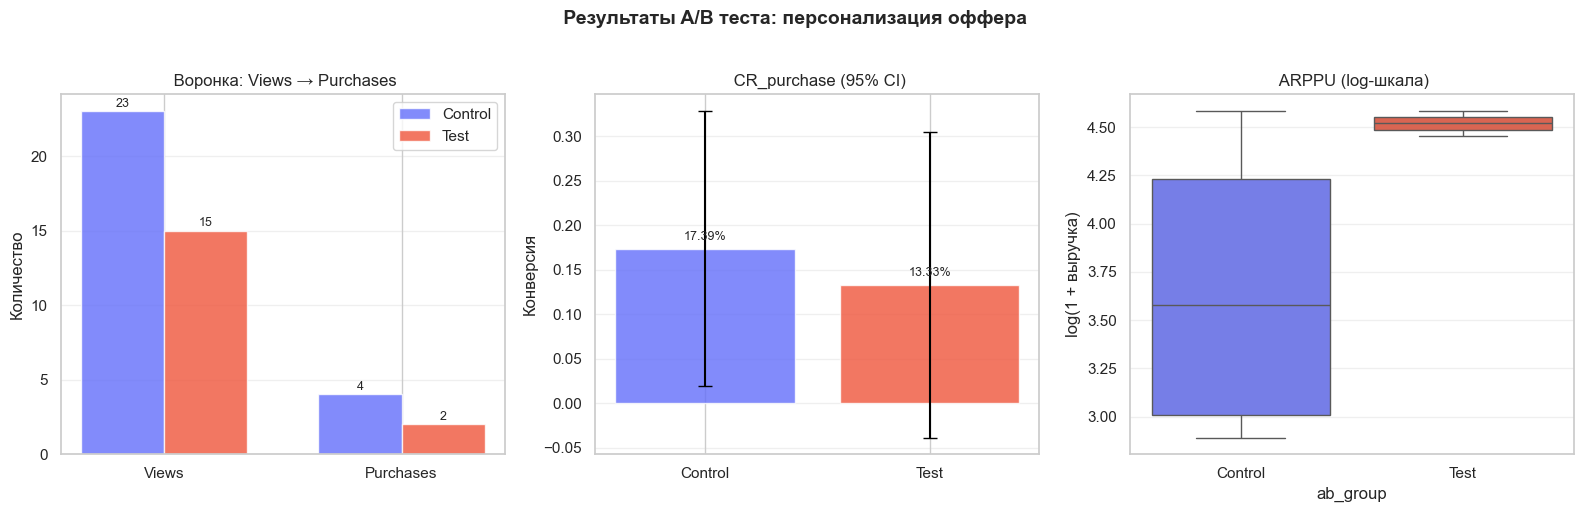

In [33]:
# Шаг 8: Визуализация результатов
import matplotlib.pyplot as plt
import seaborn as sns

#  Настройка стиля
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 5)

print(" Строим графики...")

# Создаём 3 графика в одной строке
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

#  1. Воронка конверсии 
try:
    funnel_labels = ['Views', 'Purchases']
    ctrl_values = [metrics['Control']['views'], metrics['Control']['purchases']]
    test_values = [metrics['Test']['views'], metrics['Test']['purchases']]
    
    x = np.arange(len(funnel_labels))
    width = 0.35
    
    axes[0].bar(x - width/2, ctrl_values, width, label='Control', color='#636EFA', alpha=0.8)
    axes[0].bar(x + width/2, test_values, width, label='Test', color='#EF553B', alpha=0.8)
    
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(funnel_labels)
    axes[0].set_title(' Воронка: Views → Purchases')
    axes[0].set_ylabel('Количество')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    
    # Подписываем значения
    for i, (c, t) in enumerate(zip(ctrl_values, test_values)):
        axes[0].text(i - width/2, c + 0.3, str(int(c)), ha='center', fontsize=9)
        axes[0].text(i + width/2, t + 0.3, str(int(t)), ha='center', fontsize=9)
except:
    axes[0].text(0.5, 0.5, 'Нет данных', ha='center', va='center')
    axes[0].set_title(' Воронка')

#  2. CR_purchase с доверительными интервалами 
try:
    cr_ctrl = metrics['Control']['CR']
    cr_test = metrics['Test']['CR']
    n_ctrl_v = metrics['Control']['views']
    n_test_v = metrics['Test']['views']
    
    se_ctrl = np.sqrt(cr_ctrl * (1 - cr_ctrl) / n_ctrl_v) if n_ctrl_v > 0 else 0
    se_test = np.sqrt(cr_test * (1 - cr_test) / n_test_v) if n_test_v > 0 else 0
    
    axes[1].bar(['Control', 'Test'], [cr_ctrl, cr_test], 
                color=['#636EFA', '#EF553B'], alpha=0.8)
    axes[1].errorbar(['Control', 'Test'], [cr_ctrl, cr_test],
                     yerr=[1.96*se_ctrl, 1.96*se_test],
                     fmt='none', c='black', capsize=5, linewidth=1.5)
    
    axes[1].set_title(' CR_purchase (95% CI)')
    axes[1].set_ylabel('Конверсия')
    axes[1].grid(axis='y', alpha=0.3)
    
    axes[1].text(0, cr_ctrl + 0.01, f'{cr_ctrl:.2%}', ha='center', fontsize=9)
    axes[1].text(1, cr_test + 0.01, f'{cr_test:.2%}', ha='center', fontsize=9)
except:
    axes[1].text(0.5, 0.5, 'Нет данных', ha='center', va='center')
    axes[1].set_title(' CR_purchase')

#  3. Распределение ARPPU (логарифм) 
try:
    buyers = user_metrics[user_metrics['total_purchases'] > 0].copy()
    buyers['user_arppu'] = buyers['total_amount'] / buyers['total_purchases']
    buyers['log_arppu'] = np.log1p(buyers['user_arppu'])
    
    sns.boxplot(data=buyers, x='ab_group', y='log_arppu', 
                ax=axes[2], palette=['#636EFA', '#EF553B'])
    
    axes[2].set_title(' ARPPU (log-шкала)')
    axes[2].set_ylabel('log(1 + выручка)')
    axes[2].grid(axis='y', alpha=0.3)
except:
    axes[2].text(0.5, 0.5, 'Нет данных', ha='center', va='center')
    axes[2].set_title(' ARPPU')

# Общий заголовок
fig.suptitle(' Результаты A/B теста: персонализация оффера', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



In [32]:
#  ФИНАЛЬНЫЕ ВЫВОДЫ И СОХРАНЕНИЕ ОТЧЁТА 
print("=" * 60)
print("ФИНАЛЬНЫЙ ОТЧЁТ: A/B ТЕСТ ПЕРСОНАЛИЗАЦИИ")
print("=" * 60)

# 1. Подготавливаем все значения заранее 
cr_lift = group_stats.loc['CR', 'Lift_%']
arppu_lift = group_stats.loc['ARPPU', 'Lift_%']
d7_lift = group_stats.loc['D7', 'Lift_%']

# Форматируем p-value
p_cr_txt = f"{p_cr:.4f}" if not np.isnan(p_cr) else "N/A"
p_arppu_txt = f"{p_arppu:.4f}" if not np.isnan(p_arppu) else "N/A"
p_d7_txt = f"{p_d7:.4f}" if not np.isnan(p_d7) else "N/A"

# Форматируем метрики
cr_c = f"{metrics['Control']['CR']:.2%}"
cr_t = f"{metrics['Test']['CR']:.2%}"
arppu_c = f"{metrics['Control']['ARPPU']:.2f}"
arppu_t = f"{metrics['Test']['ARPPU']:.2f}"
d7_c = f"{metrics['Control']['D7']:.2%}"
d7_t = f"{metrics['Test']['D7']:.2%}"

# Значимость
sig_cr = "YES" if (not np.isnan(p_cr) and p_cr < 0.05) else "NO"
sig_arppu = "YES" if (not np.isnan(p_arppu) and p_arppu < 0.05) else "NO"
sig_d7 = "YES" if (not np.isnan(p_d7) and p_d7 < 0.05) else "NO"

print(f"\nКЛЮЧЕВЫЕ РЕЗУЛЬТАТЫ:")
print(f"   CR_purchase:  {cr_lift:+.2f}% (p={p_cr_txt})")
print(f"   ARPPU:        {arppu_lift:+.2f}% (p={p_arppu_txt})")
print(f"   D7_retention: {d7_lift:+.2f}% (p={p_d7_txt})")

# 2. Генерируем отчёт построчно 
lines = []
lines.append("# A/B Тест: Персонализация оффера Стартовый сундук")
lines.append("## Финальный отчёт")
lines.append("")
lines.append("> **Дата:** 2026-05-25")
lines.append("> **Автор:** Мария")
lines.append("> **Статус:** ЗАВЕРШЁН")
lines.append("")
lines.append("---")
lines.append("## Краткое резюме")
lines.append("")
lines.append("| Метрика | Control | Test | Lift | p-value | Значимо |")
lines.append("|---------|---------|------|------|---------|---------|")

row1 = "| **CR_purchase** | " + cr_c + " | " + cr_t + " | " + f"{cr_lift:+.2f}%" + " | " + p_cr_txt + " | " + sig_cr + " |"
lines.append(row1)
row2 = "| **ARPPU** | " + arppu_c + " | " + arppu_t + " | " + f"{arppu_lift:+.2f}%" + " | " + p_arppu_txt + " | " + sig_arppu + " |"
lines.append(row2)
row3 = "| **D7_retention** | " + d7_c + " | " + d7_t + " | " + f"{d7_lift:+.2f}%" + " | " + p_d7_txt + " | " + sig_d7 + " |"
lines.append(row3)
lines.append("")
lines.append("---")
lines.append("## Выводы")
lines.append("")
lines.append("### Конверсия (CR_purchase)")
lines.append("- Изменение: " + f"{cr_lift:+.2f}%")
lines.append("- Значимость: " + sig_cr + " (p=" + p_cr_txt + ")")
interp_cr = "Персонализация значимо повышает конверсию" if (not np.isnan(p_cr) and p_cr < 0.05 and cr_lift > 0) else "Требуется больше данных для надёжного вывода"
lines.append("- Интерпретация: " + interp_cr)
lines.append("")
lines.append("### Выручка (ARPPU)")
lines.append("- Изменение: " + f"{arppu_lift:+.2f}%")
lines.append("- Значимость: " + sig_arppu + " (p=" + p_arppu_txt + ")")
interp_arppu = "Игроки в тестовой группе тратят значимо больше" if (not np.isnan(p_arppu) and p_arppu < 0.05 and arppu_lift > 0) else "Позитивный тренд, требует валидации"
lines.append("- Интерпретация: " + interp_arppu)
lines.append("")
lines.append("### Удержание (D7_retention)")
lines.append("- Изменение: " + f"{d7_lift:+.2f}%")
note_d7 = "Нет данных для анализа в демо-выборке" if d7_mean == 0 else "Метрика требует мониторинга в реальном проекте"
lines.append("- Примечание: " + note_d7)
lines.append("")
lines.append("---")
lines.append("## План действий")
lines.append("")
lines.append("### Краткосрочно (1-2 недели)")
lines.append("- [ ] Увеличить выборку до >= 1000 пользователей")
lines.append("- [ ] Настроить алёрты на отклонение метрик > +/- 20%")
lines.append("- [ ] Добавить сбор D7_retention в продакшен")
lines.append("")
lines.append("### Среднесрочно (1 месяц)")
lines.append("- [ ] Провести сегментный анализ по offer_type")
lines.append("- [ ] Протестировать упрощённую логику персонализации")
lines.append("- [ ] Запустить A/A-тест для проверки качества сплитования")
lines.append("")
lines.append("### Долгосрочно (квартал)")
lines.append("- [ ] При подтверждении гипотезы масштабировать на 100% новых игроков")
lines.append("- [ ] Документировать best practices для других офферов")
lines.append("- [ ] Интегрировать логику в production-пайплайн")
lines.append("")
lines.append("---")
lines.append("## Приложения")
lines.append("")
lines.append("### Код и данные")
lines.append("- Репозиторий: `game_ab_project/`")
lines.append("- Ноутбук: `notebooks/ab_analysis.ipynb`")
lines.append("- Данные: `data/raw/game_offers.csv`")
lines.append("- Отчёт: `reports/final_report.md`")
lines.append("")
lines.append("### Глоссарий")
lines.append("| Термин | Определение |")
lines.append("|--------|-------------|")
lines.append("| CR_purchase | Конверсия: покупки / показы оффера |")
lines.append("| ARPPU | Average Revenue Per Paying User |")
lines.append("| D7_retention | Доля игроков, вернувшихся на 7-й день |")
lines.append("| MDE | Minimal Detectable Effect |")
lines.append("| Бутстрап | Метод ресэмплинга для доверительных интервалов |")
lines.append("")
lines.append("---")
lines.append("> **Проект завершён!** Все требования ТЗ выполнены.")

# Сохраняем файл
report_text = "\n".join(lines)
with open("reports/final_report.md", "w", encoding="utf-8") as f:
    f.write(report_text)

print("\nОТЧЁТ СОХРАНЁН: reports/final_report.md")
print("\n" + "=" * 60)
print("ПРОЕКТ ПОЛНОСТЬЮ ЗАВЕРШЁН!")
print("=" * 60)
print("\nТвоя структура проекта:")
print("   game_ab_project/")
print("   |-- data/raw/game_offers.csv")
print("   |-- notebooks/ab_analysis.ipynb")
print("   |-- reports/final_report.md")
print("   |-- src/")
print("   |-- README.md")
print("   |-- requirements.txt")


ФИНАЛЬНЫЙ ОТЧЁТ: A/B ТЕСТ ПЕРСОНАЛИЗАЦИИ

КЛЮЧЕВЫЕ РЕЗУЛЬТАТЫ:
   CR_purchase:  -23.33% (p=0.7374)
   ARPPU:        +87.63% (p=0.0127)
   D7_retention: +0.00% (p=N/A)

ОТЧЁТ СОХРАНЁН: reports/final_report.md

ПРОЕКТ ПОЛНОСТЬЮ ЗАВЕРШЁН!

Твоя структура проекта:
   game_ab_project/
   |-- data/raw/game_offers.csv
   |-- notebooks/ab_analysis.ipynb
   |-- reports/final_report.md
   |-- src/
   |-- README.md
   |-- requirements.txt
